In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
mart_all_data = pd.read_csv('../LTV-Capstone-Project/mart_all_data.csv')
mart_all_data.head(2)

,customer_id,customer_gender,customer_location,customer_tenure_months,transaction_id,transaction_date,produkt_sku,product_category,quantity,avg_price,...,coupon_status,discount_pct,gst_onsale,offline_spend_that_day,online_spend_that_day,transaction_year,transaction_month,transaction_month_str,transaction_day_of_month,transaction_day_of_week
0,15811,F,Illinois,27,25990,2019-04-19,GGOEWCKQ085457,Accessories,1,16.99,...,Clicked,10.0,0.1,4000,1754.92,2019.0,4.0,apr,19.0,friday
1,17999,F,New Jersey,30,25038,2019-04-07,GGOEGBPB081999,Accessories,1,49.99,...,Used,10.0,0.1,2500,2719.46,2019.0,4.0,apr,7.0,sunday


In [106]:
mart_all_data.columns

Index(['customer_id', 'customer_gender', 'customer_location',
       'customer_tenure_months', 'transaction_id', 'transaction_date',
       'produkt_sku', 'product_category', 'quantity', 'avg_price',
       'delivery_charges', 'coupon_status', 'discount_pct', 'gst_onsale',
       'offline_spend_that_day', 'online_spend_that_day', 'transaction_year',
       'transaction_month', 'transaction_month_str',
       'transaction_day_of_month', 'transaction_day_of_week'],
      dtype='object')

In [107]:
# Convert transaction date to datetime
mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'])

# Extract cohort month (first transaction month of each customer)
mart_all_data['cohort_month'] = (
    mart_all_data.groupby('customer_id')['transaction_date']
    .transform('min')
    .dt.to_period('M')
)

# Extract transaction month for each purchase
mart_all_data['txn_month'] = mart_all_data['transaction_date'].dt.to_period('M')

# Calculate cohort index (0 = first month for that cohort)
mart_all_data['cohort_index'] = (
    (mart_all_data['txn_month'].dt.year - mart_all_data['cohort_month'].dt.year) * 12
    + (mart_all_data['txn_month'].dt.month - mart_all_data['cohort_month'].dt.month)
)

# Aggregate: Number of unique customers per cohort per month
cohort_data = (
    mart_all_data.groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
)


In [108]:
# Find the size of each cohort at index 0
cohort_sizes = cohort_data[cohort_data['cohort_index'] == 0][['cohort_month','customer_id']]
cohort_sizes = cohort_sizes.rename(columns={'customer_id':'cohort_size'})

# Merge sizes back
cohort_data = cohort_data.merge(cohort_sizes, on='cohort_month')
cohort_data['retention'] = cohort_data['customer_id'] / cohort_data['cohort_size']


In [109]:
cohort_pivot = cohort_data.pivot_table(
    index='cohort_index',
    columns='cohort_month',
    values='retention'
)


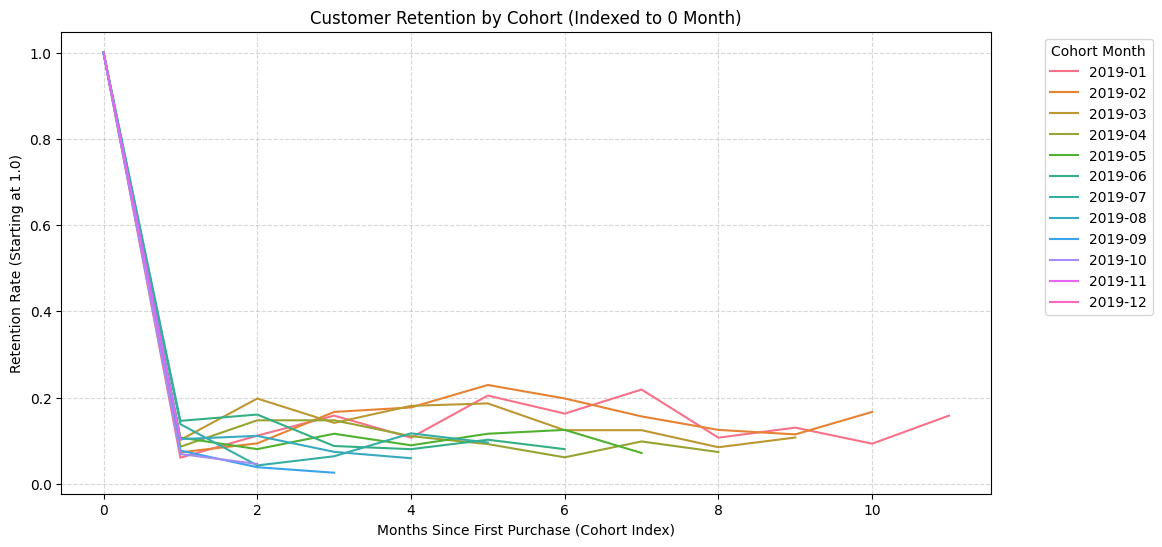

In [110]:
plt.figure(figsize=(12,6))
sns.lineplot(data=cohort_pivot, dashes=False)

plt.title('Customer Retention by Cohort (Indexed to 0 Month)')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Retention Rate (Starting at 1.0)')
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [111]:
# Cohort revenue

# Net Revenue
mart_all_data['gross_revenue'] = mart_all_data['quantity'] * mart_all_data['avg_price']

# Apply discount if present
mart_all_data['discount_amount'] = mart_all_data['gross_revenue'] * (mart_all_data['discount_pct'] / 100)

# Net revenue after discount and adding delivery & taxes
mart_all_data['transaction_amount'] = (
    mart_all_data['gross_revenue']
    - mart_all_data['discount_amount']
    + mart_all_data['delivery_charges']
    + mart_all_data['gst_onsale']
)



In [112]:
# Split Revenue by Coupon Usage
cohort_revenue_coupon = (
    mart_all_data.groupby(['cohort_month', 'coupon_status', 'cohort_index'])
    .agg(
        total_revenue=('transaction_amount', 'sum'),
        customers=('customer_id', 'nunique')
    )
    .reset_index()
)

cohort_revenue_coupon['ARPU'] = (
    cohort_revenue_coupon['total_revenue'] / cohort_revenue_coupon['customers']
)


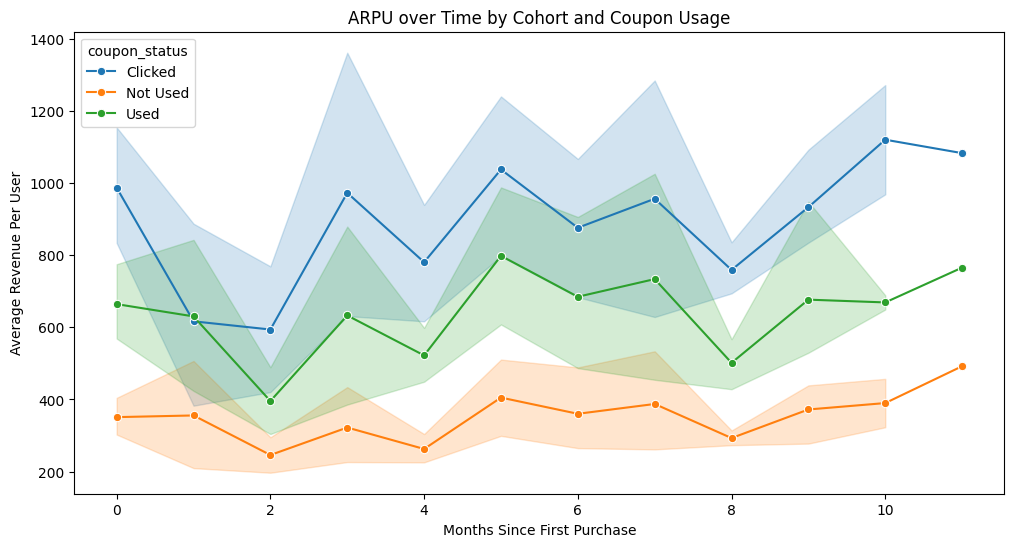

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(
    data=cohort_revenue_coupon,
    x='cohort_index',
    y='ARPU',
    hue='coupon_status',
    marker='o'
)
plt.title('ARPU over Time by Cohort and Coupon Usage')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Average Revenue Per User')
plt.show()


Note
Seaborn computes the mean ARPU per cohort index for each coupon_status and then estimates a confidence interval (by default 95%). The shaded area aound the line in the graph above is statistical uncertainty around the mean value.



In [114]:
# Purchase frequency per cohort

purchase_frequency = (
    mart_all_data.groupby(['cohort_month', 'cohort_index'])
    .agg(
        total_txns=('transaction_id', 'count'),
        customers=('customer_id', 'nunique')
    )
    .reset_index()
)
purchase_frequency['avg_txn_per_user'] = purchase_frequency['total_txns'] / purchase_frequency['customers']

Line Chart below shows how often each cohort continues purchasing over time.

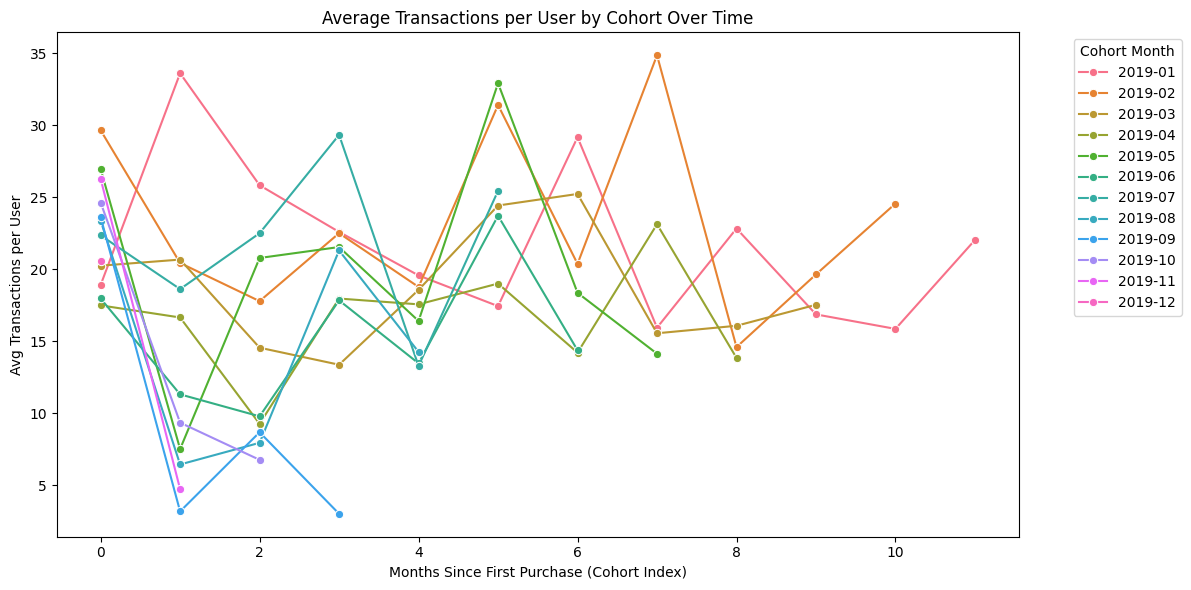

In [115]:
# Line Chart – Avg Transactions per User
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=purchase_frequency,
    x='cohort_index',
    y='avg_txn_per_user',
    hue='cohort_month',
    marker='o'
)
plt.title('Average Transactions per User by Cohort Over Time')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Avg Transactions per User')
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Heatmap of Cohorts vs Months helps to see the patterns across cohorts (e.g., if some cohorts are more engaged). The Graph quickly shows which cohorts have higher activity (darker color) in specific months.

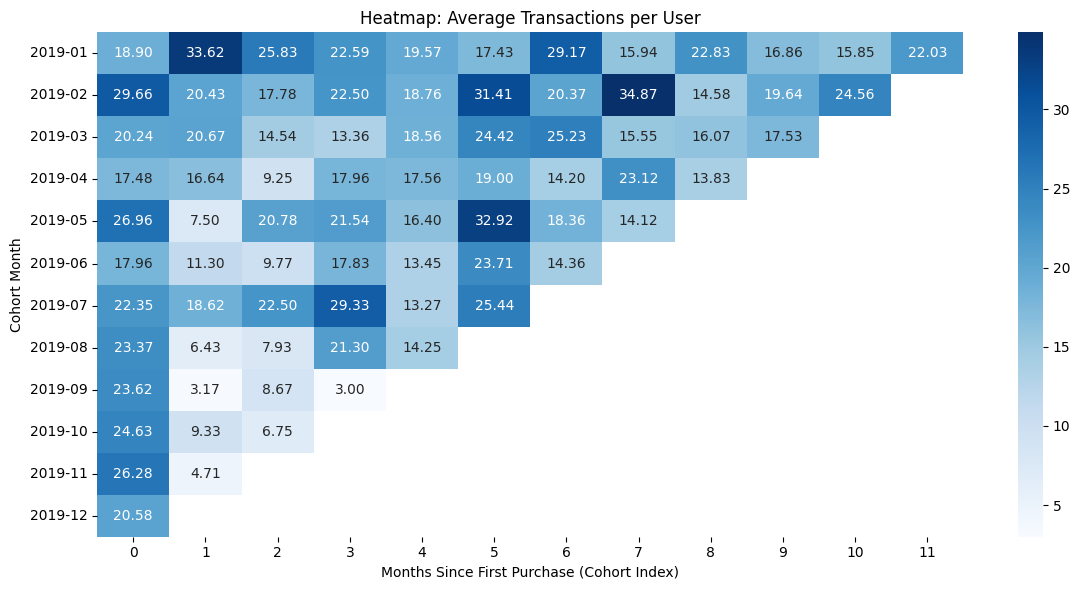

In [116]:
# Heatmap – Cohorts vs Months
# Pivot table for heatmap
pivot_freq = purchase_frequency.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='avg_txn_per_user'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_freq, annot=True, fmt=".2f", cmap='Blues')
plt.title('Heatmap: Average Transactions per User')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()


In [117]:
#  Cohort Contribution to Total Revenue
monthly_revenue = mart_all_data.groupby(['txn_month', 'cohort_month'])['transaction_amount'].sum().reset_index()

total_monthly = monthly_revenue.groupby('txn_month')['transaction_amount'].transform('sum')
monthly_revenue['cohort_share'] = monthly_revenue['transaction_amount'] / total_monthly


Stacked diagram below is used to represet a contribution of each cohort to the total revenue. Each color represents a customer acquisition cohort (month of first purchase).The stacked area chart shows how earlier cohorts decline (churn) and how new cohorts contribute revenue over time. If older cohorts retain a larger share, their band thickness stays consistent.

<Figure size 1200x600 with 0 Axes>

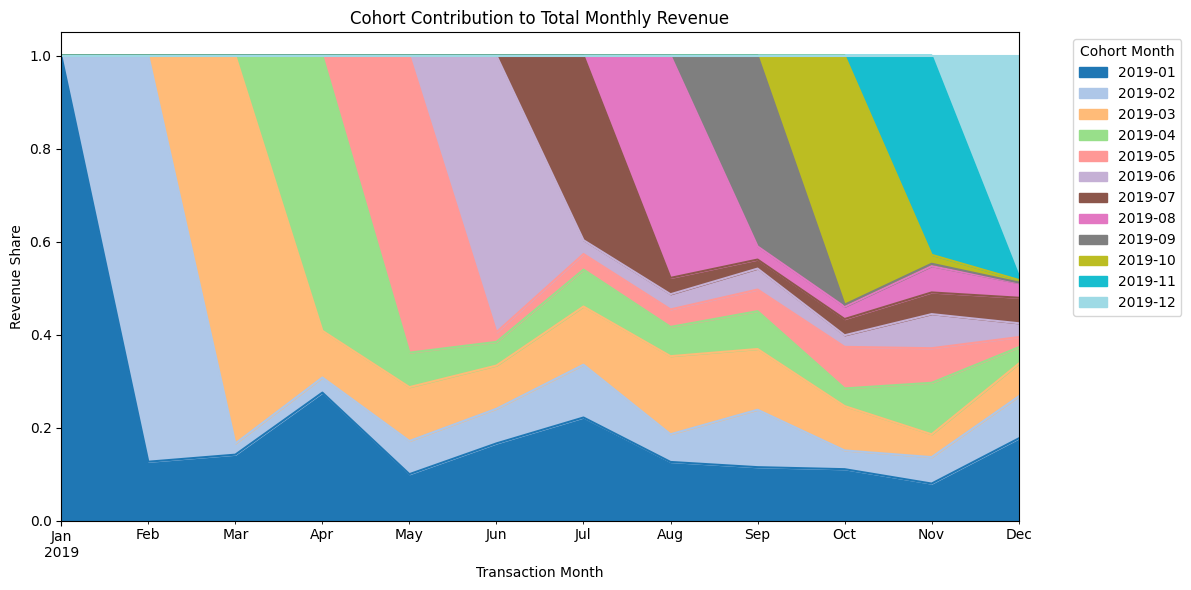

In [118]:
# Pivot data to have cohorts as columns
pivot_share = monthly_revenue.pivot(index='txn_month', columns='cohort_month', values='cohort_share')

plt.figure(figsize=(12, 6))
pivot_share.plot(kind='area', stacked=True, figsize=(12,6), colormap='tab20')

plt.title('Cohort Contribution to Total Monthly Revenue')
plt.xlabel('Transaction Month')
plt.ylabel('Revenue Share')
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


An alternative representation with a barchart.

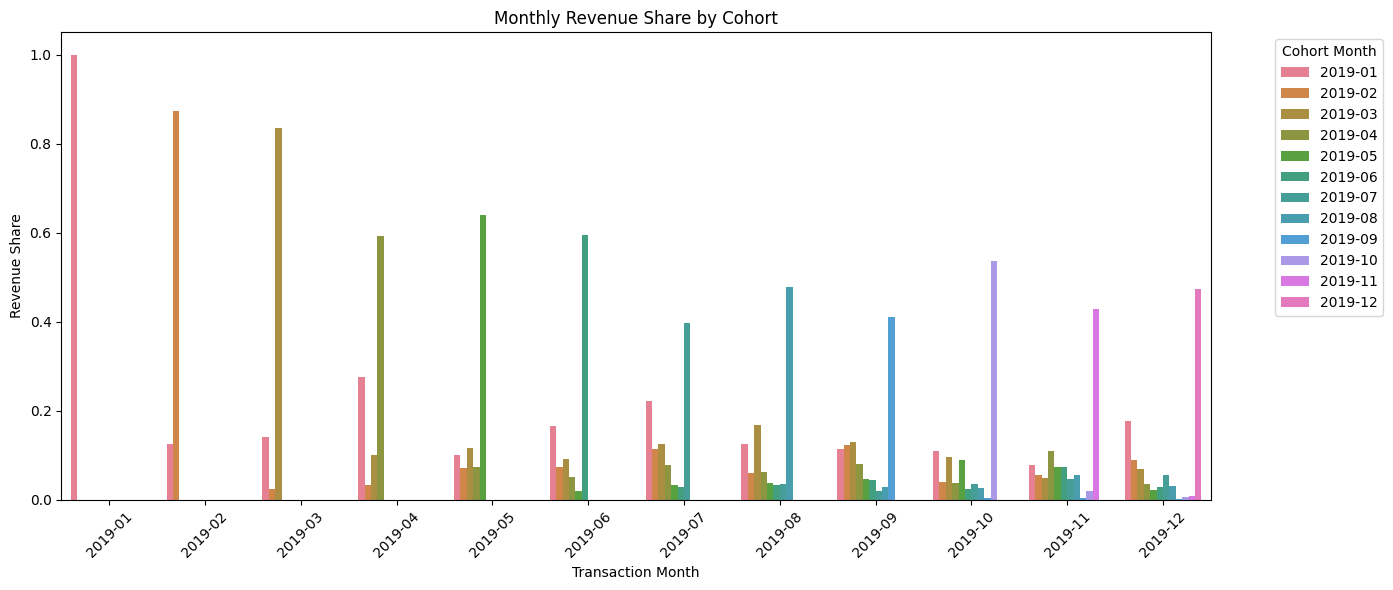

In [119]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=monthly_revenue,
    x='txn_month',
    y='cohort_share',
    hue='cohort_month'
)
plt.title('Monthly Revenue Share by Cohort')
plt.xlabel('Transaction Month')
plt.ylabel('Revenue Share')
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [120]:
#  Cohort Profitability (Net Revenue – Discounts)
mart_all_data['discount_cost'] = mart_all_data['gross_revenue'] * (mart_all_data['discount_pct'] / 100)

cohort_profit = (
    mart_all_data.groupby(['cohort_month', 'cohort_index'])
    .agg(
        net_revenue=('transaction_amount', 'sum'),
        total_discount=('discount_cost', 'sum')
    )
    .reset_index()
)

cohort_profit['profit_margin'] = (
    (cohort_profit['net_revenue'] - cohort_profit['total_discount']) / cohort_profit['net_revenue']
)


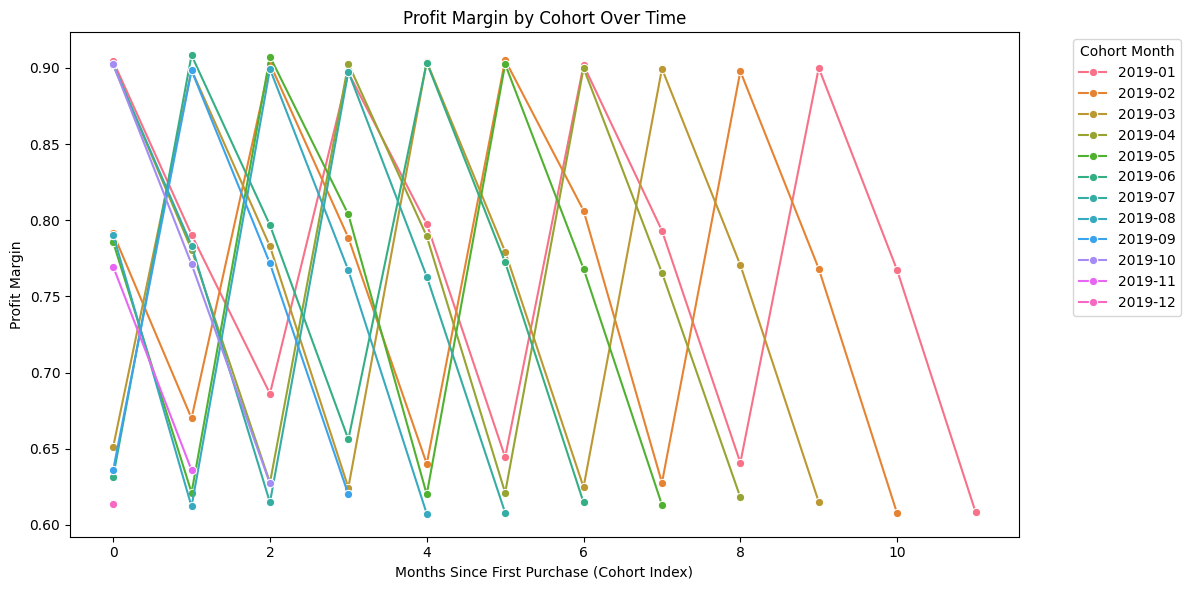

In [121]:
#  Line Chart – Profit Margin Trend Over Time shows if some cohorts have increasing or decreasing profitability over time

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=cohort_profit,
    x='cohort_index',
    y='profit_margin',
    hue='cohort_month',
    marker='o'
)
plt.title('Profit Margin by Cohort Over Time')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Profit Margin')
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


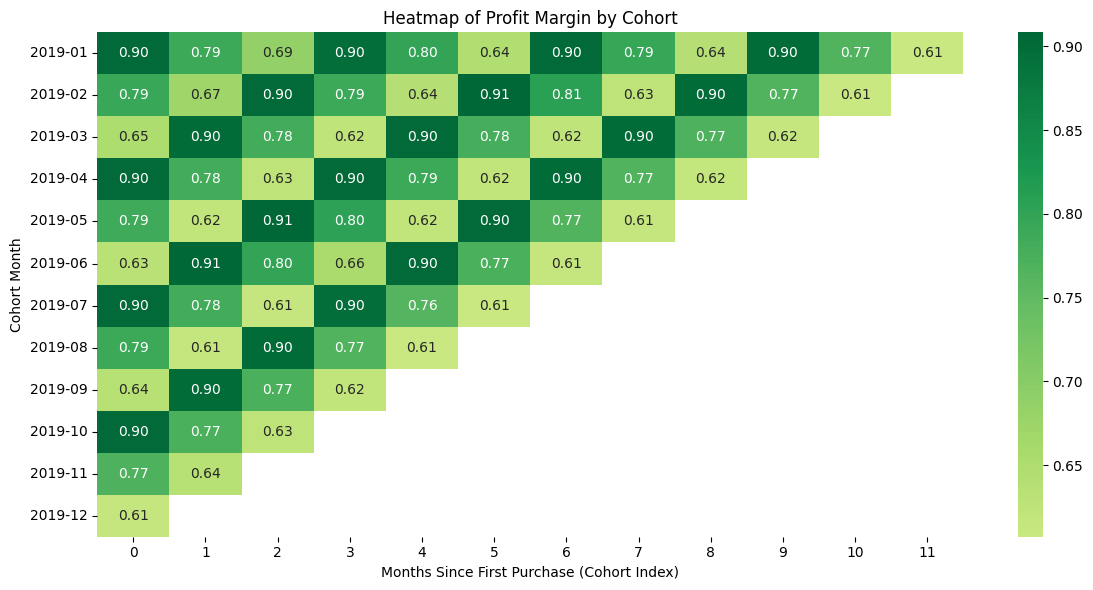

In [122]:
# Pivot data for heatmap helps to identify high or low profit cohorts at a glance (green = high margin, red = low).
pivot_profit = cohort_profit.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='profit_margin'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_profit, annot=True, fmt=".2f", cmap='RdYlGn', center=0.5)
plt.title('Heatmap of Profit Margin by Cohort')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()


In [123]:
#  Customer Segmentation Within Cohorts by Gender
segmented = mart_all_data.groupby(['cohort_month', 'customer_gender', 'cohort_index'])['customer_id'].nunique().reset_index()

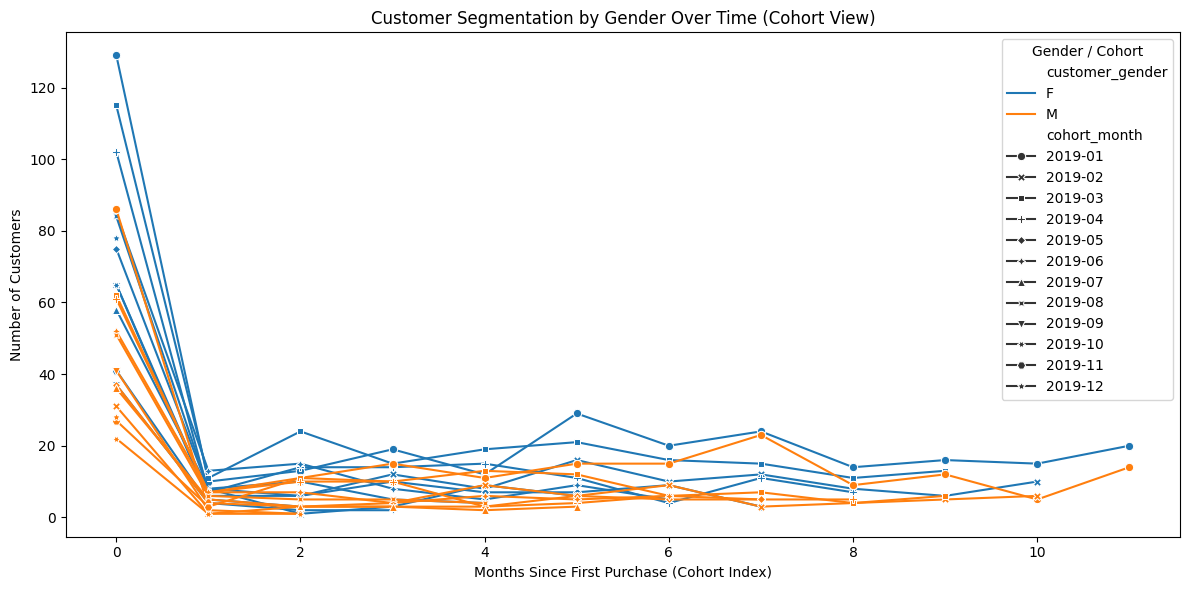

In [124]:
# Grouped Line Chart (Trend of Customer Count per Gender in Each Cohort) 
# shows how the number of customers evolves over time for each gender within each cohort.

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=segmented,
    x='cohort_index',
    y='customer_id',
    hue='customer_gender',
    style='cohort_month',
    markers=True,
    dashes=False
)
plt.title('Customer Segmentation by Gender Over Time (Cohort View)')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Number of Customers')
plt.legend(title='Gender / Cohort')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

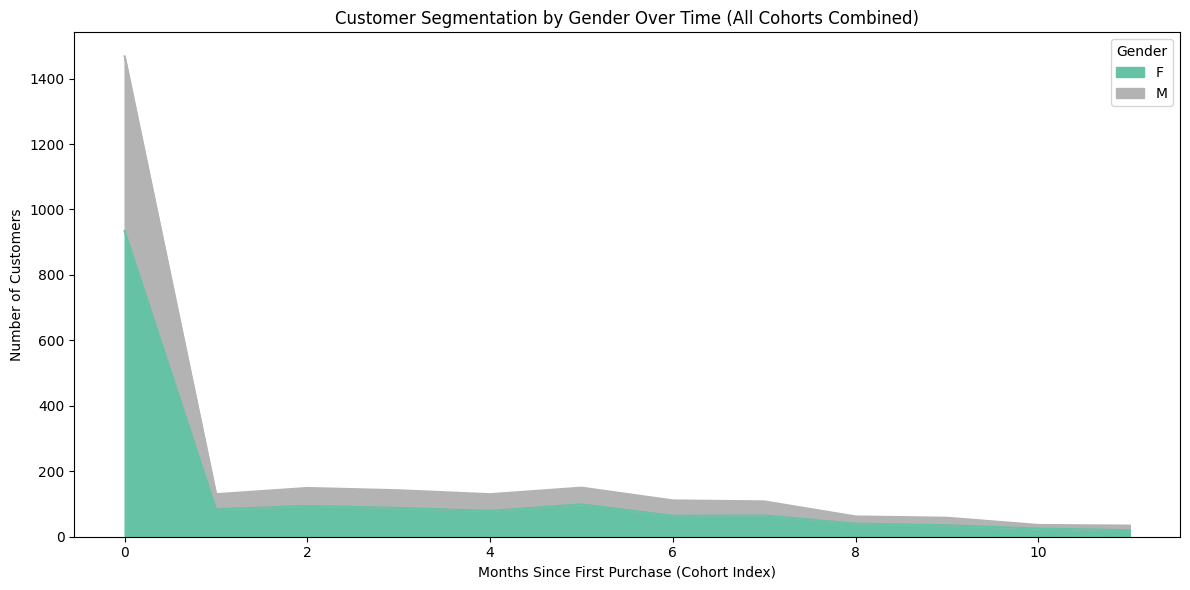

In [125]:
# Share of genders in purchases or activity by month. 
# Pivot data for stacked area
pivot_segment = segmented.pivot_table(
    index=['cohort_index'],
    columns='customer_gender',
    values='customer_id',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12, 6))
pivot_segment.plot(kind='area', stacked=True, cmap='Set2', figsize=(12,6))
plt.title('Customer Segmentation by Gender Over Time (All Cohorts Combined)')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Number of Customers')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


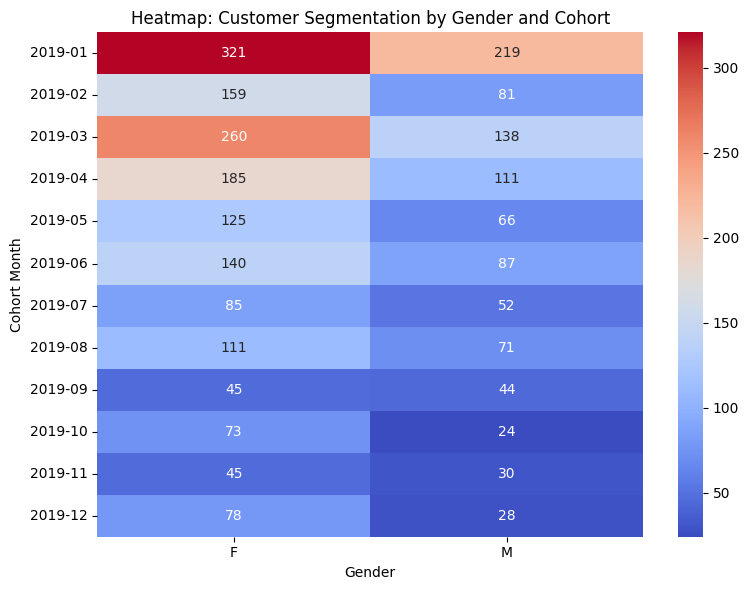

In [126]:
# The Heatmap shows if some certain cohorts are more skewed towards one gender.
# A matrix view helps to understand which cohorts have more of a specific gender.
pivot_heatmap = segmented.pivot_table(
    index='cohort_month',
    columns='customer_gender',
    values='customer_id',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_heatmap, annot=True, fmt="d", cmap="coolwarm")
plt.title('Heatmap: Customer Segmentation by Gender and Cohort')
plt.xlabel('Gender')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()


In [127]:
#!pip install lifelines
#Lifelines package is used for survival analysis and customer lifetime modeling.

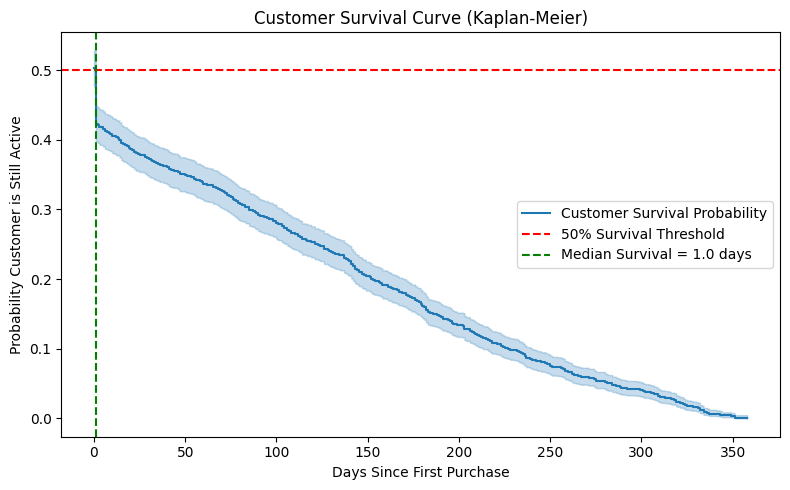

In [128]:
#  Time to Churn / Survival Analysis
from lifelines import KaplanMeierFitter

# Calculate observation end date
observation_end = mart_all_data['transaction_date'].max()

# Compute customer lifespan
customer_lifespan = (
    mart_all_data.groupby('customer_id')
    .agg(
        first_purchase=('transaction_date', 'min'),
        last_purchase=('transaction_date', 'max')
    )
)

# Duration in days
customer_lifespan['lifespan_days'] = (
    customer_lifespan['last_purchase'] - customer_lifespan['first_purchase']
).dt.days

# Event observed: 1 if churned (last purchase < observation_end), else 0 (right-censored)
customer_lifespan['event_observed'] = (
    customer_lifespan['last_purchase'] < observation_end
).astype(int)

# Fit Kaplan-Meier model
kmf = KaplanMeierFitter()
kmf.fit(
    durations=customer_lifespan['lifespan_days'],
    event_observed=customer_lifespan['event_observed'],
    label='Customer Survival Probability'
)

# Get median survival time
median_survival = kmf.median_survival_time_

# Plot survival function
plt.figure(figsize=(8, 5))
kmf.plot_survival_function(ci_show=True)
plt.axhline(0.5, color='red', linestyle='--', label='50% Survival Threshold')
plt.axvline(median_survival, color='green', linestyle='--',
            label=f'Median Survival = {median_survival} days')
plt.title('Customer Survival Curve (Kaplan-Meier)')
plt.xlabel('Days Since First Purchase')
plt.ylabel('Probability Customer is Still Active')
plt.legend()
plt.tight_layout()
plt.show()

The Kaplan-Meier estimator is a non-parametric statistic used to estimate the probability that a subject (customer) “survives” (remains active) past a certain time. It calculates a survival probability curve based on the lifespan durations.
- X-axis: Time in days since first purchase
- Y-axis: Probability that a customer is still active after x days
The curve typically decreases over time as more customers become inactive (no repeat purchases).

Interpretation
- Steep drop early on: Many customers stop purchasing soon after acquisition.
- Flat tail: A small segment of loyal customers continues purchasing long-term.
- Median survival time: The point where survival probability = 0.5 (50% of customers are still active).

Limitations
- Assumes that every customer has "churned" after their last purchase (no censored data handling)
- It does not account for ongoing observation windows (customers who might still be active but haven't purchased recently).

Note
Customer Lifetime Value (CLV), the median survival time helps answer: "How long does the typical customer stay active (make purchases) before churning?"

Why median survival time matters for CLV:
- It estimates the typical customer lifespan.
- Helps in forecasting expected revenue period.
- Useful for segmenting customers by retention risk.
- Helps optimize marketing spend by targeting customers likely to stay longer.

In the analysis below median survival time for coupon users is higher than for non-users. This implies that Coupon usage may increase customer retention, extending the customer lifespan.This can lead to higher overall lifetime value for coupon users.
Coupons might be an effective tool to improve loyalty and reduce churn!
You might want to segment customers by coupon usage for targeted marketing.

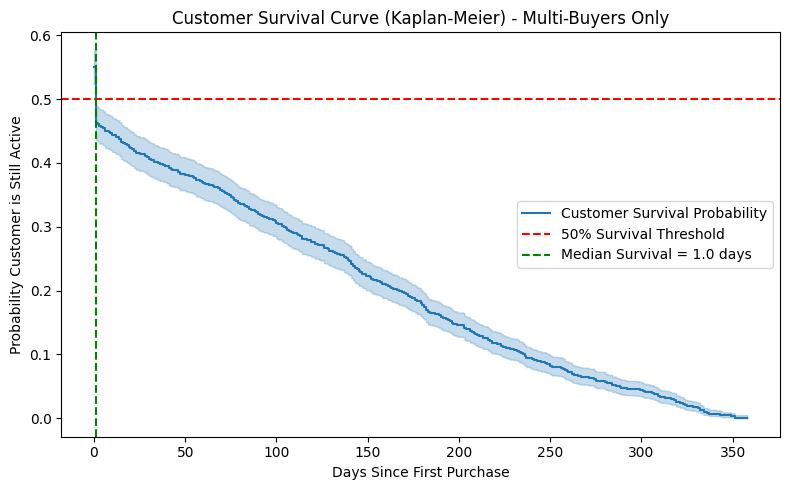

In [129]:
# Adjusted Code: Exclude Non-Buyers or Single-Purchase Customers in the code above.
# - Filters out "one-time buyers" who can't have a measurable "time to churn."
# - Survival curve now reflects actual repeat customer retention, not single-purchase customers.
# - Median survival time should now increase beyond 1 day and give a meaningful retention duration.


import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Count transactions per customer
customer_txn_counts = mart_all_data.groupby('customer_id')['transaction_id'].nunique()

# Keep only customers with more than 1 purchase
multi_buyers = customer_txn_counts[customer_txn_counts > 1].index
filtered_data = mart_all_data[mart_all_data['customer_id'].isin(multi_buyers)]

# Calculate observation end date
observation_end = filtered_data['transaction_date'].max()

# Compute customer lifespan
customer_lifespan = (
    filtered_data.groupby('customer_id')
    .agg(
        first_purchase=('transaction_date', 'min'),
        last_purchase=('transaction_date', 'max')
    )
)

# Duration in days
customer_lifespan['lifespan_days'] = (
    customer_lifespan['last_purchase'] - customer_lifespan['first_purchase']
).dt.days

# Event observed: churn = last purchase < observation end
customer_lifespan['event_observed'] = (
    customer_lifespan['last_purchase'] < observation_end
).astype(int)

# Fit Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(
    durations=customer_lifespan['lifespan_days'],
    event_observed=customer_lifespan['event_observed'],
    label='Customer Survival Probability'
)

# Get median survival time
median_survival = kmf.median_survival_time_

# Plot
plt.figure(figsize=(8, 5))
kmf.plot_survival_function(ci_show=True)
plt.axhline(0.5, color='red', linestyle='--', label='50% Survival Threshold')
plt.axvline(median_survival, color='green', linestyle='--',
            label=f'Median Survival = {median_survival} days')
plt.title('Customer Survival Curve (Kaplan-Meier) - Multi-Buyers Only')
plt.xlabel('Days Since First Purchase')
plt.ylabel('Probability Customer is Still Active')
plt.legend()
plt.tight_layout()
plt.show()


In [130]:
#  Repeat Purchase Probability
repeat_purchase = (
    mart_all_data.groupby('customer_id')['transaction_id']
    .count()
    .value_counts(normalize=True)
)


In [131]:
#  Cross-Sell and Product Affinity by Cohort. 
# Track whether cohorts expand their product categories over time:
# 1)Number of unique product categories purchased per user per cohort. 
# 2)Shows how customers evolve in their buying behavior.

category_spread = (
    mart_all_data.groupby(['customer_id', 'cohort_month'])['product_category']
    .nunique()
    .groupby('cohort_month')
    .mean()
)


coupon_status
Clicked     26926
Used        17904
Not Used     8094
Name: count, dtype: int64


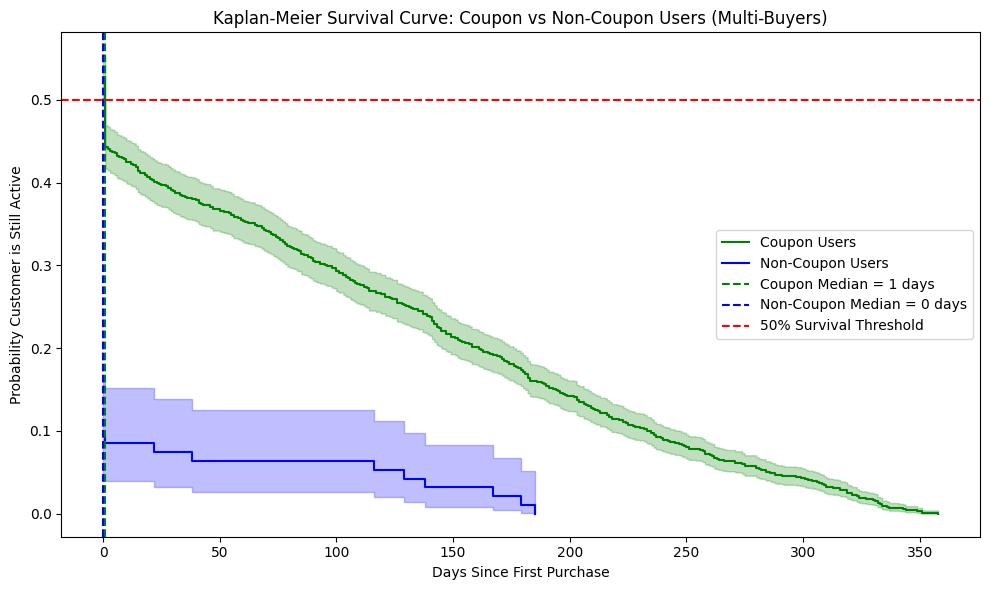

In [132]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1. Inspect coupon_status values (optional)
print(mart_all_data['coupon_status'].value_counts(dropna=False))

# 2. Map categorical values to binary used_coupon flag based on coupon_status
mart_all_data['used_coupon'] = mart_all_data['coupon_status'].map({
    'Used': 1,
    'Clicked': 0,    # Change to 1 if you want to treat 'Clicked' as coupon used
    'Not Used': 0
}).fillna(0)

# 3. Build customer-level summary
customer_summary = (
    mart_all_data.groupby('customer_id')
    .agg(
        first_purchase=('transaction_date', 'min'),
        last_purchase=('transaction_date', 'max'),
        used_coupon=('used_coupon', 'max')  # max indicates if customer ever used coupon
    )
)

# 4. Calculate lifespan and event observed
customer_summary['lifespan_days'] = (customer_summary['last_purchase'] - customer_summary['first_purchase']).dt.days
customer_summary['event_observed'] = 1  # Assume all customers churn (or use actual event data if available)

# 5. Define masks for coupon and non-coupon users
mask_coupon = customer_summary['used_coupon'] == 1
mask_non_coupon = customer_summary['used_coupon'] == 0

# 6. Initialize Kaplan-Meier fitter instances
kmf_coupon = KaplanMeierFitter()
kmf_non_coupon = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

# 7. Plot coupon users survival curve if data exists
if mask_coupon.sum() > 0:
    kmf_coupon.fit(
        durations=customer_summary.loc[mask_coupon, 'lifespan_days'],
        event_observed=customer_summary.loc[mask_coupon, 'event_observed'],
        label='Coupon Users'
    )
    kmf_coupon.plot_survival_function(ci_show=True, color='green')
else:
    print("No coupon users with valid data.")

# 8. Plot non-coupon users survival curve if data exists
if mask_non_coupon.sum() > 0:
    kmf_non_coupon.fit(
        durations=customer_summary.loc[mask_non_coupon, 'lifespan_days'],
        event_observed=customer_summary.loc[mask_non_coupon, 'event_observed'],
        label='Non-Coupon Users'
    )
    kmf_non_coupon.plot_survival_function(ci_show=True, color='blue')
else:
    print("No non-coupon users with valid data.")

# 9. Add median survival time vertical lines if groups exist
if mask_coupon.sum() > 0:
    plt.axvline(kmf_coupon.median_survival_time_, color='green', linestyle='--',
                label=f'Coupon Median = {int(kmf_coupon.median_survival_time_)} days')
if mask_non_coupon.sum() > 0:
    plt.axvline(kmf_non_coupon.median_survival_time_, color='blue', linestyle='--',
                label=f'Non-Coupon Median = {int(kmf_non_coupon.median_survival_time_)} days')

# 10. Add horizontal 50% survival threshold line and labels
plt.axhline(0.5, color='red', linestyle='--', label='50% Survival Threshold')
plt.title('Kaplan-Meier Survival Curve: Coupon vs Non-Coupon Users (Multi-Buyers)')
plt.xlabel('Days Since First Purchase')
plt.ylabel('Probability Customer is Still Active')
plt.legend()
plt.tight_layout()
plt.show()